# Cleaned beginner-friendly Ridge regression notebook

This notebook is simplified for learning. It loads the data, engineers a few time features and simple lag features, does a time-aware split (no leakage), scales numeric features, fits a Ridge regression with built-in CV, and shows evaluation metrics and a parity plot.

Loaded rows, cols: (6435, 8)
Features shape: (6255, 10)
Train rows, Test rows: 5004 1251
Best alpha: 0.001
R2: 0.9979 | RMSE: 17748.79 | MAE: 6274.33


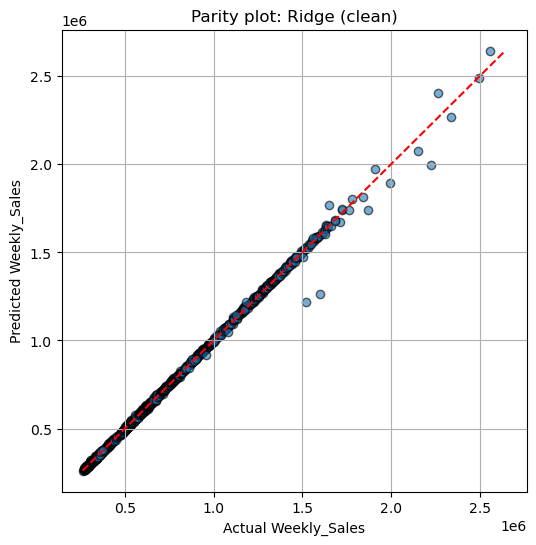

In [51]:
# Simple and clear pipeline (beginner-friendly)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# 1) Load data (adjust path if necessary)
df = pd.read_csv('walmart-sales-dataset-of-45stores.csv', parse_dates=['Date'], dayfirst=True)
print('Loaded rows, cols:', df.shape)

# 2) Basic cleaning: keep target and remove rows with missing target
df = df.dropna(subset=['Weekly_Sales']).copy()

# 3) Time features (if Date exists)
if 'Date' in df.columns:
    df = df.sort_values('Date').reset_index(drop=True)
    df['Month'] = df['Date'].dt.month
    df['DayOfWeek'] = df['Date'].dt.dayofweek
    # drop Date after extracting simple features to avoid dtype issues
    df = df.drop(columns=['Date'])

# 4) Simple lag features (previous week's sales) grouped by Store & Dept if available
group_cols = [c for c in ['Store','Dept'] if c in df.columns]
if group_cols:
    df = df.sort_values(group_cols + ['Weekly_Sales']).reset_index(drop=True)
    df['Sales_Lag1'] = df.groupby(group_cols)['Weekly_Sales'].shift(1)
else:
    df['Sales_Lag1'] = df['Weekly_Sales'].shift(1)

# 5) Rolling mean (previous 4 entries)
if group_cols:
    # use transform so the result aligns with the DataFrame index
    df['Sales_Roll4'] = df.groupby(group_cols)['Weekly_Sales'].transform(lambda x: x.shift(1).rolling(4).mean())
else:
    df['Sales_Roll4'] = df['Weekly_Sales'].shift(1).rolling(4).mean()

# 6) Drop rows with NaNs created by lags/rolling
df = df.dropna().reset_index(drop=True)

# 7) Simple frequency encoding for Store/Dept (keeps things numeric and simple)
for c in ['Store', 'Dept']:
    if c in df.columns:
        freq = df[c].value_counts(normalize=True)
        df[c + '_freq'] = df[c].map(freq).fillna(0)
        df = df.drop(columns=[c])

# 8) Prepare X and y
y = df['Weekly_Sales']
X = df.drop(columns=['Weekly_Sales'])
print('Features shape:', X.shape)

# 9) Time-aware split: first 80% train, last 20% test
cut = int(len(df) * 0.8)
X_train = X.iloc[:cut].copy()
X_test = X.iloc[cut:].copy()
y_train = y.iloc[:cut].copy()
y_test = y.iloc[cut:].copy()
print('Train rows, Test rows:', X_train.shape[0], X_test.shape[0])

# 10) Impute simple missing values on numeric/categorical separately (if any)
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object','category']).columns.tolist()
if len(num_cols) > 0:
    X_train[num_cols] = SimpleImputer(strategy='mean').fit_transform(X_train[num_cols])
    X_test[num_cols] = SimpleImputer(strategy='mean').fit_transform(X_test[num_cols])
if len(cat_cols) > 0:
    X_train[cat_cols] = SimpleImputer(strategy='most_frequent').fit_transform(X_train[cat_cols])
    X_test[cat_cols] = SimpleImputer(strategy='most_frequent').fit_transform(X_test[cat_cols])

# 11) Scale numeric features (fit on train only)
scaler = StandardScaler()
X_train.loc[:, num_cols] = scaler.fit_transform(X_train[num_cols])
X_test.loc[:, num_cols] = scaler.transform(X_test[num_cols])

# 12) Train a simple Ridge with built-in CV for alpha selection
alphas = np.logspace(-3, 3, 30)
model = RidgeCV(alphas=alphas, cv=5)
model.fit(X_train, y_train)

# 13) Evaluate on test set
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
print(f'Best alpha: {model.alpha_}')
print(f'R2: {r2:.4f} | RMSE: {rmse:.2f} | MAE: {mae:.2f}')

# 14) Parity plot
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='k')
mn, mx = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
plt.plot([mn, mx], [mn, mx], 'r--')
plt.xlabel('Actual Weekly_Sales')
plt.ylabel('Predicted Weekly_Sales')
plt.title('Parity plot: Ridge (clean)')
plt.grid(True)
plt.show()